<a href="https://colab.research.google.com/github/biruhyos/dsrp-sp500/blob/main/DSRP_S%26P_500_Biruh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('/content/sp500 (1).csv')
df

,Date,SP500,Dividend,Earnings,Consumer Price Index,Long Interest Rate,Real Price,Real Dividend,Real Earnings,PE10
0,1871-01-01,4.44,0.26,0.4,12.46,5.32,109.05,6.39,9.82,0.0
1,1871-02-01,4.50,0.26,0.4,12.84,5.32,107.25,6.20,9.53,0.0
2,1871-03-01,4.61,0.26,0.4,13.03,5.33,108.27,6.11,9.39,0.0
3,1871-04-01,4.74,0.26,0.4,12.56,5.33,115.54,6.34,9.75,0.0
4,1871-05-01,4.86,0.26,0.4,12.27,5.33,121.22,6.48,9.98,0.0
...,...,...,...,...,...,...,...,...,...,...
1860,2026-01-01,6929.12,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.0
1861,2026-02-01,6893.81,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.0
1862,2026-03-01,6654.42,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.0
1863,2026-04-01,6957.01,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.0


In [2]:
print('DataFrame Shape:')
df.shape

DataFrame Shape:


(1865, 10)

In [3]:
print('DataFrame Columns:')
df.columns

DataFrame Columns:


Index(['Date', 'SP500', 'Dividend', 'Earnings', 'Consumer Price Index',
       'Long Interest Rate', 'Real Price', 'Real Dividend', 'Real Earnings',
       'PE10'],
      dtype='object')

In [4]:
df = df.rename(columns={'PE10': 'Shiller_PE_Ratio'})

print('Updated DataFrame Columns:')
df.columns

Updated DataFrame Columns:


Index(['Date', 'SP500', 'Dividend', 'Earnings', 'Consumer Price Index',
       'Long Interest Rate', 'Real Price', 'Real Dividend', 'Real Earnings',
       'Shiller_PE_Ratio'],
      dtype='object')

In [5]:
print('DataFrame Info:')
df.info()

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1865 entries, 0 to 1864
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  1865 non-null   object 
 1   SP500                 1865 non-null   float64
 2   Dividend              1865 non-null   float64
 3   Earnings              1865 non-null   float64
 4   Consumer Price Index  1865 non-null   float64
 5   Long Interest Rate    1865 non-null   float64
 6   Real Price            1865 non-null   float64
 7   Real Dividend         1865 non-null   float64
 8   Real Earnings         1865 non-null   float64
 9   Shiller_PE_Ratio      1865 non-null   float64
dtypes: float64(9), object(1)
memory usage: 145.8+ KB


In [6]:
print('DataFrame Description:')
df.describe()

DataFrame Description:


,SP500,Dividend,Earnings,Consumer Price Index,Long Interest Rate,Real Price,Real Dividend,Real Earnings,Shiller_PE_Ratio
count,1865.000000,1865.000000,1865.000000,1865.000000,1865.000000,1865.000000,1865.000000,1865.000000,1865.000000
mean,471.260650,7.341378,17.253457,64.207480,4.410391,731.026804,19.865668,40.400402,15.983534
std,1078.137653,13.555434,34.337819,79.898101,2.351200,912.750421,13.665336,37.714948,8.378767
min,2.730000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,8.040000,0.400000,0.523300,10.100000,3.120000,207.500000,10.320000,15.290000,11.030000
50%,19.830000,0.856667,1.426000,19.900000,3.770000,315.610000,16.070000,26.010000,15.760000
75%,263.700000,7.356670,14.820000,105.300000,5.050000,802.570000,25.280000,49.350000,20.550000
max,7412.550000,68.710000,197.910000,306.130000,15.320000,5140.590000,71.220000,217.260000,44.200000


In [7]:
df.drop_duplicates(inplace=True)
print('DataFrame after dropping duplicates:')
df.head()

DataFrame after dropping duplicates:


,Date,SP500,Dividend,Earnings,Consumer Price Index,Long Interest Rate,Real Price,Real Dividend,Real Earnings,Shiller_PE_Ratio
0,1871-01-01,4.44,0.26,0.4,12.46,5.32,109.05,6.39,9.82,0.0
1,1871-02-01,4.50,0.26,0.4,12.84,5.32,107.25,6.20,9.53,0.0
2,1871-03-01,4.61,0.26,0.4,13.03,5.33,108.27,6.11,9.39,0.0
3,1871-04-01,4.74,0.26,0.4,12.56,5.33,115.54,6.34,9.75,0.0
4,1871-05-01,4.86,0.26,0.4,12.27,5.33,121.22,6.48,9.98,0.0


In [8]:
df['Date'] = pd.to_datetime(df['Date'])
print('DataFrame Info after converting Date column:')
df.info()

DataFrame Info after converting Date column:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1865 entries, 0 to 1864
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Date                  1865 non-null   datetime64[ns]
 1   SP500                 1865 non-null   float64       
 2   Dividend              1865 non-null   float64       
 3   Earnings              1865 non-null   float64       
 4   Consumer Price Index  1865 non-null   float64       
 5   Long Interest Rate    1865 non-null   float64       
 6   Real Price            1865 non-null   float64       
 7   Real Dividend         1865 non-null   float64       
 8   Real Earnings         1865 non-null   float64       
 9   Shiller_PE_Ratio      1865 non-null   float64       
dtypes: datetime64[ns](1), float64(9)
memory usage: 145.8 KB


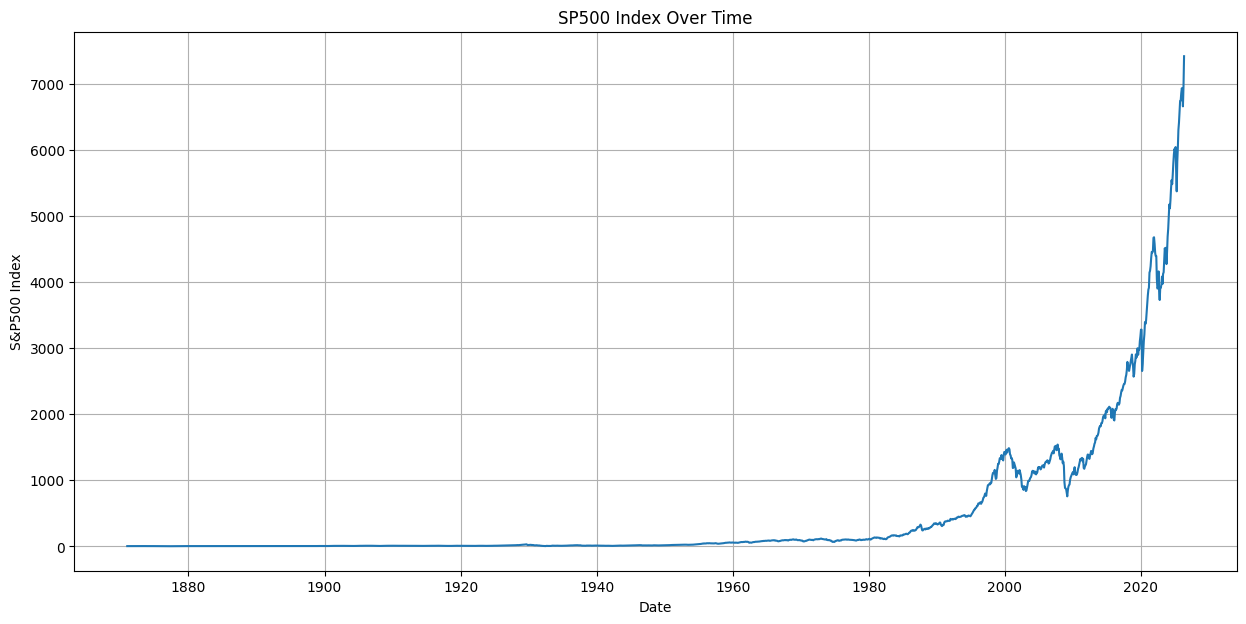

In [9]:
plt.figure(figsize=(15, 7))
plt.plot(df['Date'], df['SP500'])
plt.title('SP500 Index Over Time')
plt.xlabel('Date')
plt.ylabel('S&P500 Index')
plt.grid(True)
plt.show()

In [10]:
# Define the start and end dates for our filter
start_date = '1881-01-01'
end_date = '2023-12-31'

# Filter the DataFrame to keep only the rows within this date range
# We use '&' to combine two conditions: 'Date' must be greater than or equal to start_date,
# AND 'Date' must be less than or equal to end_date.
df_filtered_dates = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)]

# The first few rows and last few rows of our new filtered DataFrame
print("DataFrame after filtering by date (head):")
display(df_filtered_dates.head())

print("\nDataFrame after filtering by date (tail):")
display(df_filtered_dates.tail())

print(f"\nOriginal number of rows: {len(df)}")
print(f"Number of rows after date filtering: {len(df_filtered_dates)}")

DataFrame after filtering by date (head):


,Date,SP500,Dividend,Earnings,Consumer Price Index,Long Interest Rate,Real Price,Real Dividend,Real Earnings,Shiller_PE_Ratio
120,1881-01-01,6.19,0.265,0.4858,9.42,3.70,201.17,8.61,15.79,18.47
121,1881-02-01,6.17,0.270,0.4817,9.51,3.69,198.52,8.69,15.50,18.15
122,1881-03-01,6.24,0.275,0.4775,9.51,3.69,200.77,8.85,15.36,18.27
123,1881-04-01,6.22,0.280,0.4733,9.61,3.68,198.15,8.92,15.08,17.95
124,1881-05-01,6.50,0.285,0.4692,9.51,3.67,209.13,9.17,15.10,18.87



DataFrame after filtering by date (tail):


,Date,SP500,Dividend,Earnings,Consumer Price Index,Long Interest Rate,Real Price,Real Dividend,Real Earnings,Shiller_PE_Ratio
1831,2023-08-01,4457.358696,0.0,0.0,305.98,4.17,4459.48,0.0,0.0,30.47
1832,2023-09-01,4515.770000,0.0,0.0,306.13,4.09,4515.77,0.0,0.0,30.81
1833,2023-10-01,4269.400000,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.00
1834,2023-11-01,4460.060000,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.00
1835,2023-12-01,4685.050000,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.00



Original number of rows: 1865
Number of rows after date filtering: 1716


In [11]:
columns_to_check_for_zeros = [
    'SP500', 'Dividend', 'Earnings', 'Real Price',
    'Real Dividend', 'Real Earnings', 'Shiller_PE_Ratio'
]

# Create a boolean mask where any of the specified columns are 0.0
zero_mask = (df_filtered_dates[columns_to_check_for_zeros] == 0.0).any(axis=1)

# Filter out rows where any of the specified columns are 0.0
df_cleaned = df_filtered_dates[~zero_mask].copy()

print(f"Number of rows before cleaning 0.0 placeholders: {len(df_filtered_dates)}")
print(f"Number of rows after cleaning 0.0 placeholders: {len(df_cleaned)}")

display(df_cleaned.head())
display(df_cleaned.tail())

Number of rows before cleaning 0.0 placeholders: 1716
Number of rows after cleaning 0.0 placeholders: 1710


,Date,SP500,Dividend,Earnings,Consumer Price Index,Long Interest Rate,Real Price,Real Dividend,Real Earnings,Shiller_PE_Ratio
120,1881-01-01,6.19,0.265,0.4858,9.42,3.70,201.17,8.61,15.79,18.47
121,1881-02-01,6.17,0.270,0.4817,9.51,3.69,198.52,8.69,15.50,18.15
122,1881-03-01,6.24,0.275,0.4775,9.51,3.69,200.77,8.85,15.36,18.27
123,1881-04-01,6.22,0.280,0.4733,9.61,3.68,198.15,8.92,15.08,17.95
124,1881-05-01,6.50,0.285,0.4692,9.51,3.67,209.13,9.17,15.10,18.87


,Date,SP500,Dividend,Earnings,Consumer Price Index,Long Interest Rate,Real Price,Real Dividend,Real Earnings,Shiller_PE_Ratio
1825,2023-02-01,4079.684737,67.780000,174.363333,300.84,3.75,4151.39,68.97,177.43,28.92
1826,2023-03-01,3968.559130,68.210000,175.170000,301.67,3.66,4027.13,69.22,177.76,27.95
1827,2023-04-01,4121.467368,68.376667,177.170000,303.36,3.46,4159.03,69.00,178.78,28.76
1828,2023-05-01,4146.173182,68.543333,179.170000,304.13,3.57,4173.45,68.99,180.35,28.76
1829,2023-06-01,4345.372857,68.710000,181.170000,305.11,3.75,4359.88,68.94,181.77,29.94


In [12]:
df_final_cleaned = df_cleaned[(df_cleaned['Shiller_PE_Ratio'] > 0) & (df_cleaned['SP500'] > 0)].copy()
print(f"Rows: {df_final_cleaned.shape[0]} | Date range: {df_final_cleaned['Date'].min()} to {df_final_cleaned['Date'].max()}")
corr = df_final_cleaned['Long Interest Rate'].corr(df_final_cleaned['Shiller_PE_Ratio'])
print(f"Correlation: {corr:.3f}")

Rows: 1710 | Date range: 1881-01-01 00:00:00 to 2023-06-01 00:00:00
Correlation: -0.214


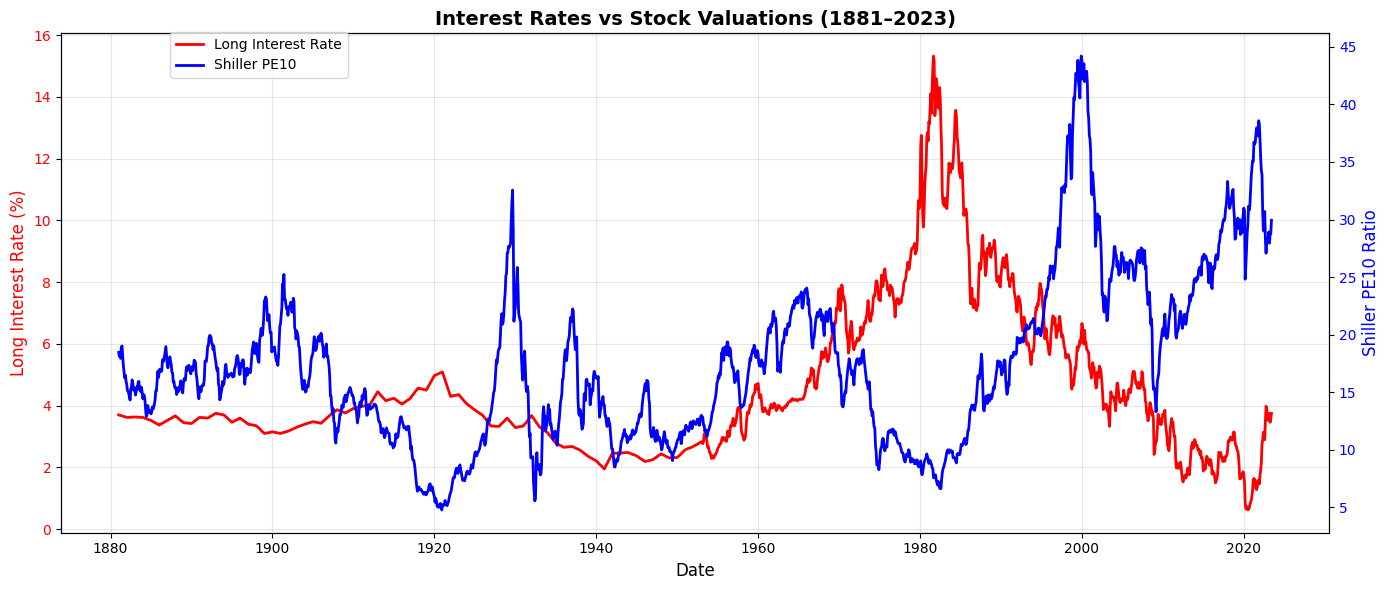

In [13]:
import matplotlib.pyplot as plt


fig, ax1 = plt.subplots(figsize=(14, 6))

# Plot Interest Rates on left axis
ax1.plot(df_final_cleaned['Date'], df_final_cleaned['Long Interest Rate'], color='red', label='Long Interest Rate', linewidth=2)
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Long Interest Rate (%)', color='red', fontsize=12)
ax1.tick_params(axis='y', labelcolor='red')
ax1.grid(True, alpha=0.3)

# Plot PE10 on right axis
ax2 = ax1.twinx()
ax2.plot(df_final_cleaned['Date'], df_final_cleaned['Shiller_PE_Ratio'], color='blue', label='Shiller PE10', linewidth=2)
ax2.set_ylabel('Shiller PE10 Ratio', color='blue', fontsize=12)
ax2.tick_params(axis='y', labelcolor='blue')


plt.title('Interest Rates vs Stock Valuations (1881–2023)', fontsize=14, fontweight='bold')
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.95))
plt.tight_layout()
plt.show()